In [ ]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

%matplotlib widget


In [ ]:
condition = "3mod_basic_s126_a05"
checkpoint_epoch = 0
n_samples_test = 1000
split = "test"

experiment_name = get_experiment_name(condition, "biased_00", 0)
global_workspace, domain_mods, gw_mod, visual_module, original_colors, original_attr, original_v_latents, cat, latent_domains = get_modules_data_from_exp(experiment_name=experiment_name, n_samples_test=n_samples_test, split=split, checkpoint_epoch=checkpoint_epoch)

In [9]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def evaluate_robust_transfer(objects, category, n_per_cat=3, n_iterations=50):
    """
    Exécute l'évaluation n_iterations fois pour obtenir des stats robustes.
    """
    all_results = {"z_spatial": [], "z_couleur": [], "z_vision_2": [], "z_syn": [], "z_syn_fusion": []}
    y = torch.argmax(category, dim=1).cpu().numpy() if category.dim() > 1 else category.cpu().numpy()
    
    for i in range(n_iterations):
        for name, data in [("z_spatial", objects["z_spatial"]), ("z_couleur", objects["z_couleur"]), ("z_vision_2", objects["z_vision_2"]), ("z_syn", objects["z_syn"]), ("z_syn_fusion", objects["z_syn_fusion"])]:
            X = data.detach().cpu().numpy()

            train_size = n_per_cat*3/1000
            
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, train_size=train_size, stratify=y
            )

            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)   # fit sur train seulement
            X_test  = scaler.transform(X_test)        # transform sur test
            
            clf = LogisticRegression(max_iter=1000, solver='lbfgs')
            clf.fit(X_train, y_train)
            
            all_results[name].append(clf.score(X_test, y_test))

    stats = {}
    for name in all_results:
        scores = np.array(all_results[name])
        stats[name] = {
            "mean": np.mean(scores),
            "std": np.std(scores),
            "ci_95": 1.96 * np.std(scores) / np.sqrt(n_iterations)
        }
        
    return stats


In [15]:
r = []
epochs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50]
n_per_cat = [ 2, 3, 4, 5, 10, 50, 100, 200]

for i in n_per_cat:
    experiment_name = get_experiment_name(condition, "biased_00", 0)
    global_workspace, domain_mods, gw_mod, visual_module, original_colors, original_attr, original_v_latents, cat, latent_domains = get_modules_data_from_exp(experiment_name=experiment_name, n_samples_test=n_samples_test, split=split, checkpoint_epoch=0)

    objects = get_objects_from_v_latents(latent_domains, gw_mod, global_workspace)

    res = evaluate_robust_transfer(objects, cat, n_per_cat=i, n_iterations=50)
    r.append({i: res})

/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
/home/luc

Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/3mod_basic_s126_a05_biased_00/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/3mod_basic_s126_a05_biased_00/checkpoints/last.ckpt


/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explic

Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/3mod_basic_s126_a05_biased_00/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/3mod_basic_s126_a05_biased_00/checkpoints/last.ckpt


/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explic

...

/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explic

Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/3mod_basic_s126_a05_biased_00/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/3mod_basic_s126_a05_biased_00/checkpoints/last.ckpt


/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explic

Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/3mod_basic_s126_a05_biased_00/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/3mod_basic_s126_a05_biased_00/checkpoints/last.ckpt


/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/torch/nn/modules/module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


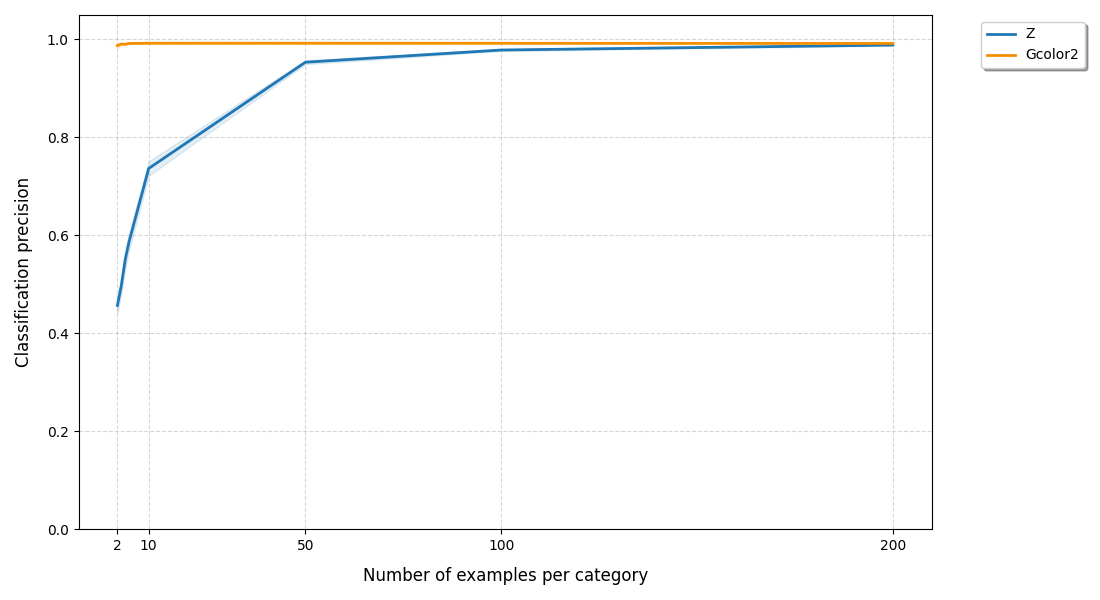

In [17]:
import matplotlib.pyplot as plt
import numpy as np
# Import indispensable pour forcer les entiers sur l'axe
from matplotlib.ticker import MaxNLocator

DISPLAY_CONFIG = {
    'z_spatial': False,
    'z_couleur': False,
    'z_vision_2': True,
    'z_syn': True,
    'z_syn_fusion': False,
}

history = r[0:30]

keys = sorted([list(epoch_dict.keys())[0] for epoch_dict in history])

# On ajoute une clé 'label' pour contrôler le texte de la légende de chaque élément
style_config = {
    'z_spatial': {'color': '#0a304a', 'label': 'Gw spatial'},
    'z_couleur': {'color': '#39803f', 'label': 'Gw couleur'},
    'z_vision_2': {'color': '#1f77b4', 'label': 'Z'},
    'z_syn': {'color': '#f58f00', 'label': 'Gcolor2'},
    'z_syn_fusion': {'color': '#d62728', 'label': 'Gw syn + Gw spatial'}
}

plt.figure(figsize=(11, 6))
for key, should_display in DISPLAY_CONFIG.items():
    if should_display:
        means = []
        cis = []
        for epoch_dict in history:
            epoch_num = list(epoch_dict.keys())[0]
            data = epoch_dict[epoch_num][key]
            means.append(data['mean'])
            cis.append(data['ci_95'])
        means = np.array(means)
        cis = np.array(cis)

        color = style_config[key]['color']
        custom_label = style_config[key]['label']

        plt.plot(keys, means, label=custom_label,
                 color=color, linewidth=2, markersize=6)
        plt.fill_between(keys, means - cis, means + cis,
                         color=color, alpha=0.12)

plt.xlabel("Number of examples per category", fontsize=12, labelpad=10)
plt.ylabel("Classification precision", fontsize=12, labelpad=10)

ax = plt.gca()
plt.xticks([2, 10, 50, 100, 200])                   # ← une valeur de tick par entrée dans keys
plt.ylim(0, 1.05)                   # ← 5% de marge au-dessus de 1

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, shadow=True)
plt.tight_layout()
plt.show()